In [ ]:
%matplotlib widget
import os
import numpy as np
import pandas as pd
import neurokit2 as nk

DATA_FS = 500 # Hz

In [ ]:
####### Parameters
normalize = False

####### LOAD DATA
path_data = "../../../stressid-dataset/Physiological/"

filelist = [f for f_sub in [f_names for root, d_names, f_names in os.walk(path_data)] for f in f_sub]
dirlist = [d for d_sub in [d_names for root, d_names, f_names in os.walk(path_data)] for d in d_sub]

data_ecg = dict()
data_eda = dict()
data_rsp = dict()

filelist.sort()

for i in filelist:
    if not i.startswith("."):
        path = os.path.join(path_data, i.split("_")[0] + "/")
        file = pd.read_csv(path + i, sep=",")
        if file.isnull().sum().sum() != 0:
            print("There are ", file.isnull().sum().sum(), " nan values in the recording", i)

        file_ecg = np.array(file["ECG"])
        file_eda = np.array(file["EDA"])

        # Normalization
        filename = i.split(".")[0]
        task = filename.split("_")[1]

        if normalize:
            ecg_std = file_ecg.std()
            ecg_out = np.zeros_like(file_ecg, dtype=float)
            np.divide(file_ecg - file_ecg.mean(), ecg_std, out=ecg_out, where=ecg_std != 0)
            data_ecg[filename] = ecg_out

            eda_std = file_eda.std()
            eda_out = np.zeros_like(file_eda, dtype=float)
            np.divide(file_eda - file_eda.mean(), eda_std, out=eda_out, where=eda_std != 0)
            data_eda[filename] = eda_out
        else:
            data_ecg[filename] = file_ecg
            data_eda[filename] = file_eda


####### CLEAN USING NK
ecg_clean = data_ecg.copy()
eda_clean = data_eda.copy()

for ecg, eda in zip(data_ecg.items(), data_eda.items()):
    ecg_clean[ecg[0]] = nk.ecg_clean(ecg[1], sampling_rate=DATA_FS, method="biosppy")
    eda_clean[eda[0]] = nk.eda_clean(eda[1], sampling_rate=DATA_FS, method="biosppy")

In [ ]:
import matplotlib.pyplot as plt
from IPython.display import display

from scipy.signal import resample, medfilt

RESULTS_DIR = "./Results"

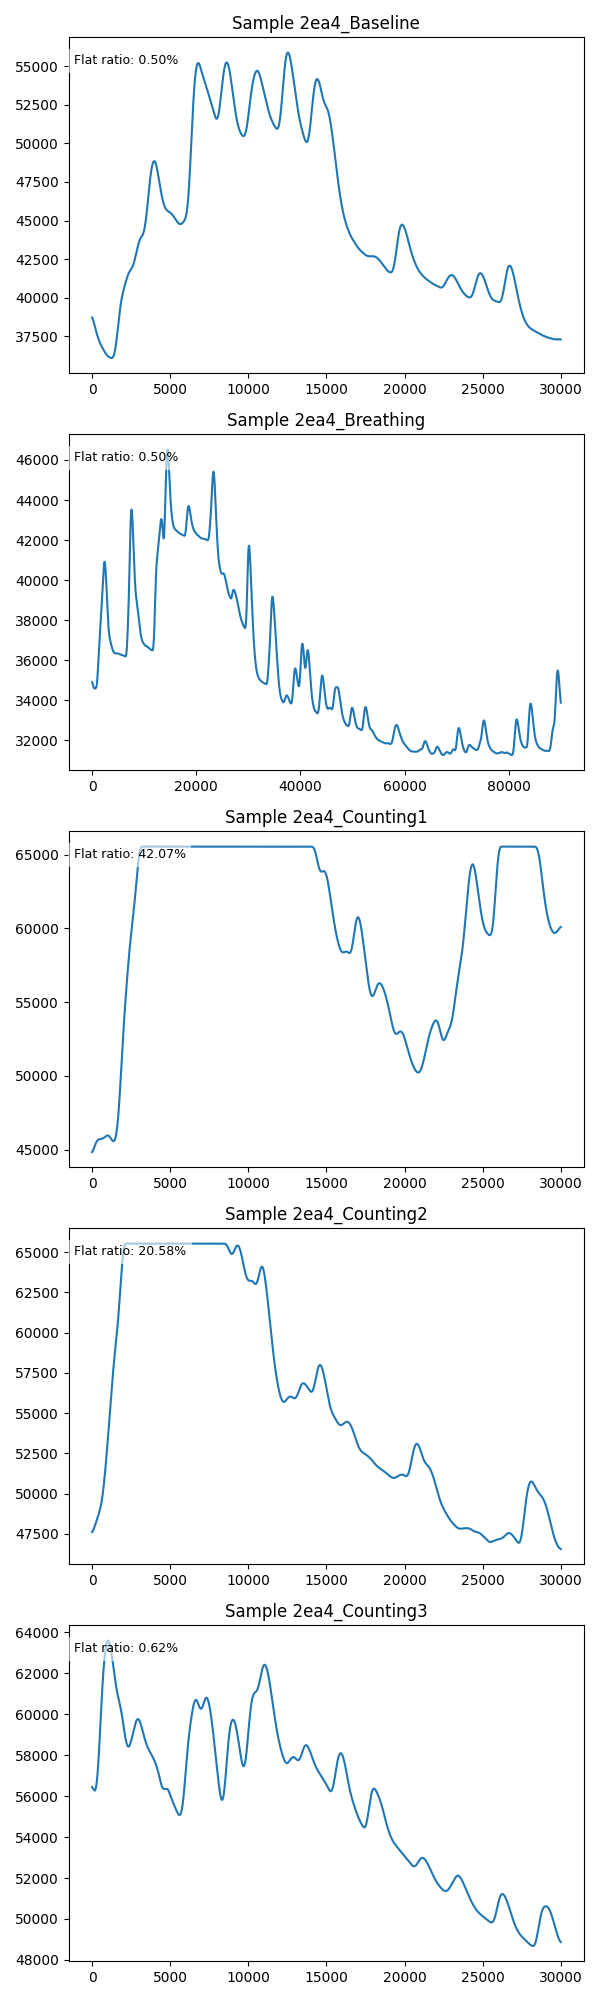

Samples with more than 5% of missing data 27. Total samples: 774. Rate: 3.488372093023256


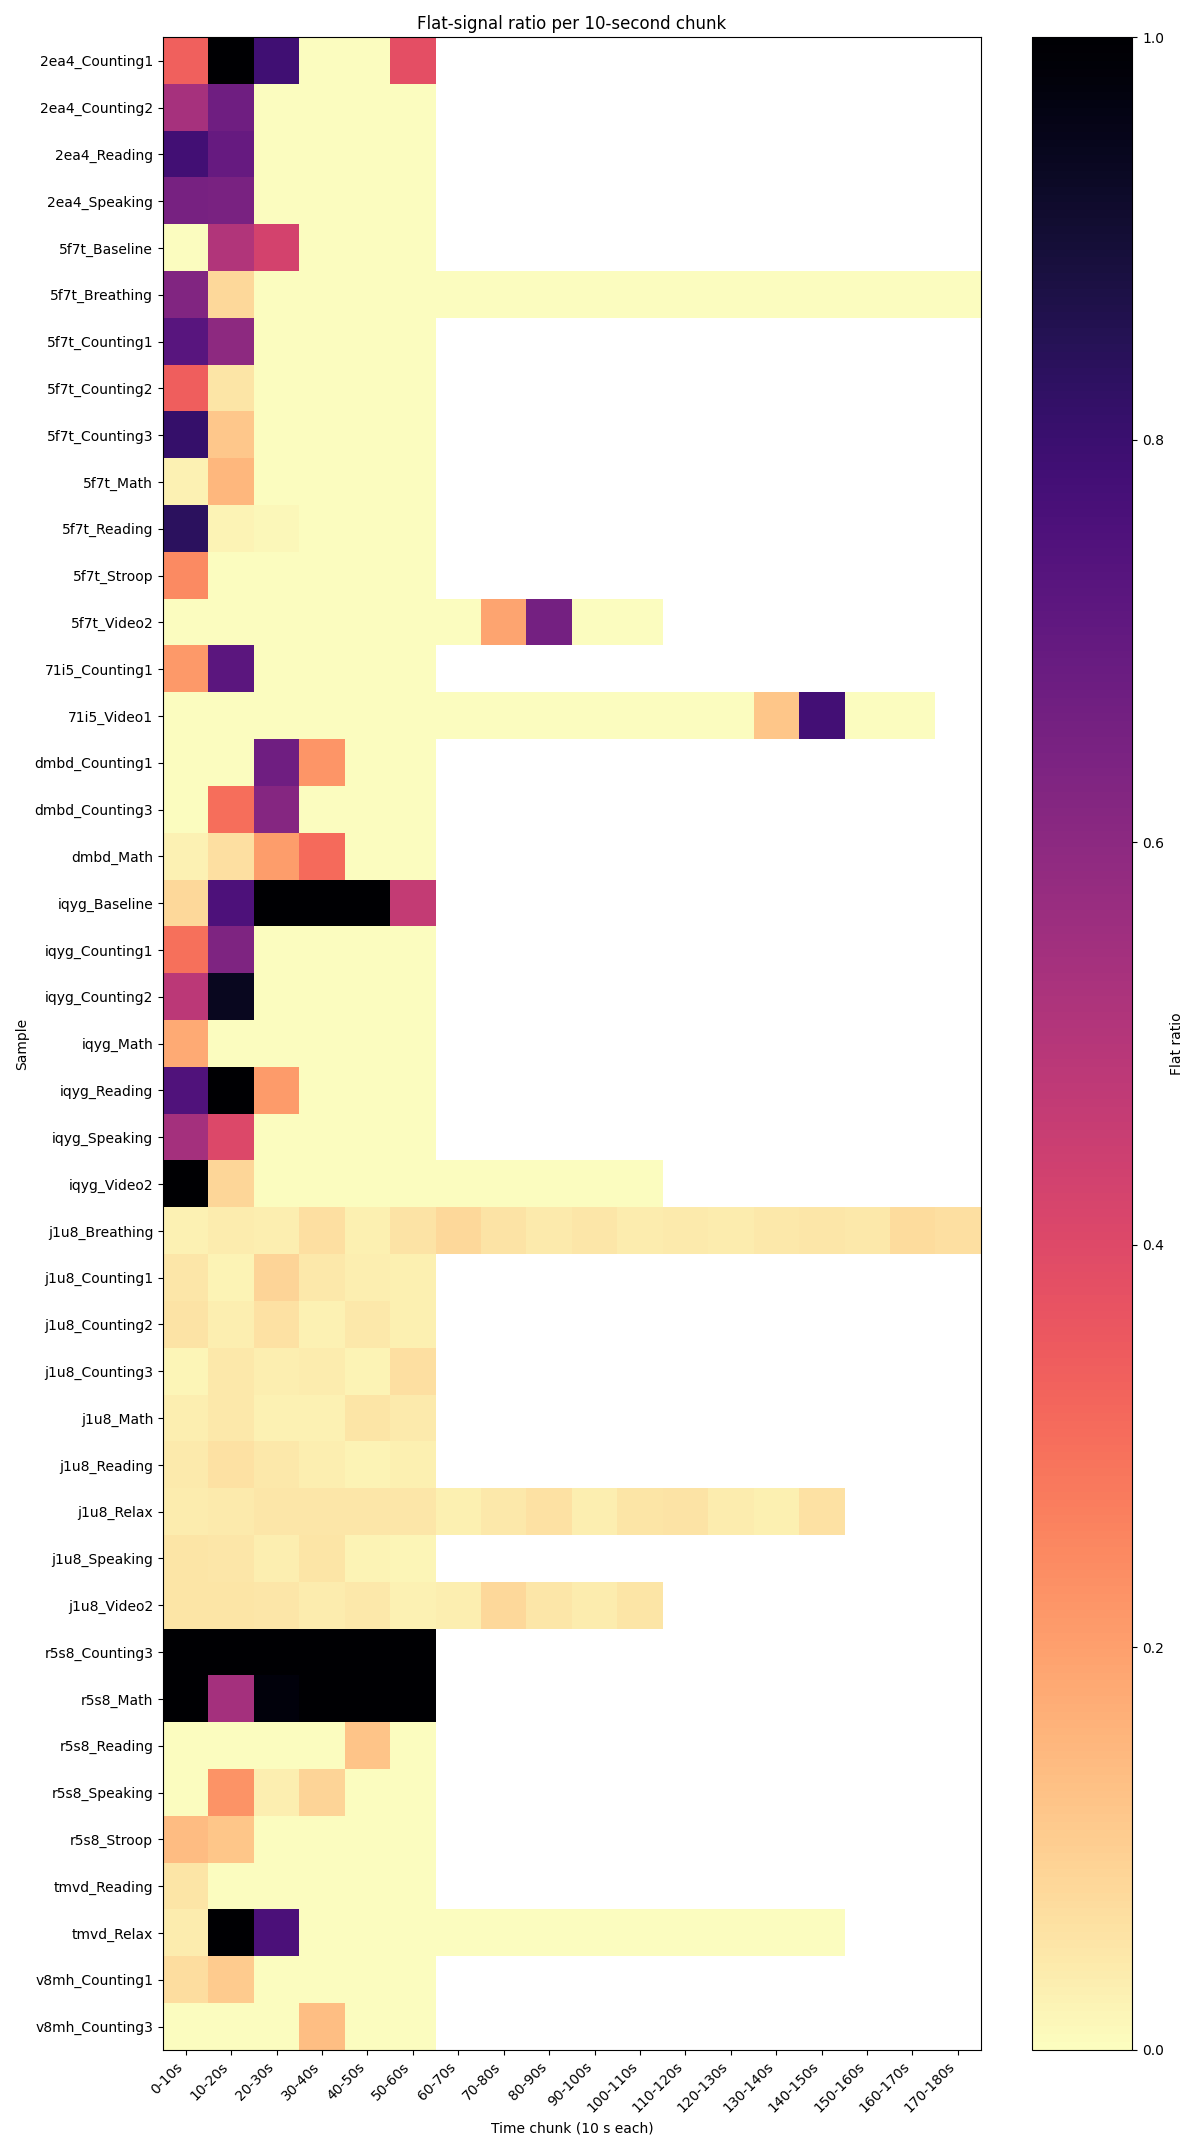

In [ ]:
from math import floor

SHOW_N_SAMPLES = 5
DO_BREAK = True  # Whether to stop or not after SHOW_N_SAMPLES
SHOWS_NCOLS = 1
SHOW_NROWS = SHOW_N_SAMPLES
FIGSIZE = (6, 4 * SHOW_NROWS)
fig, axes = plt.subplots(SHOW_NROWS, SHOWS_NCOLS, figsize=FIGSIZE)

FLAT_DIFF_THRESHOLD = 1e-4
SHOW_SAMPLE_FLAT_THRESHOLD = 0.05 # Percetange of flat signal needed to get displayed


def compute_flat_signal_ratio(signal: np.ndarray, diff_threshold: float = FLAT_DIFF_THRESHOLD) -> float:
    """Return fraction of samples that remain flat (changes below diff_threshold).

    Samples that belong to a flat segment are marked by checking whether their
    neighbours change less than the configured threshold.
    """
    if signal.size < 2:
        return 0.0

    diffs = np.abs(np.diff(signal))
    nearly_flat = diffs <= diff_threshold
    left_flat = np.concatenate((nearly_flat, [False]))
    right_flat = np.concatenate(([False], nearly_flat))
    flat_mask = left_flat | right_flat
    return float(flat_mask.sum() / flat_mask.size)


ax_counter = 0
sample_quality: dict[str, list[float]] = {"sample_name": [], "flat_signal_rate": []}

for sample_name, sample_data in eda_clean.items():
    # print(f'Analysis for "{sample_name}" classes')
    smoothed = medfilt(sample_data, kernel_size=11)
    flat_rate = compute_flat_signal_ratio(smoothed)
    sample_quality["sample_name"].append(sample_name)
    sample_quality["flat_signal_rate"].append(flat_rate)
    # print(f"    Flat signal ratio: {flat_rate:.2%}")

    if ax_counter < SHOW_N_SAMPLES:
        axes[ax_counter].set_title(f"Sample {sample_name}")
        axes[ax_counter].plot(sample_data, label="EDA")
        axes[ax_counter].text(
            0.01,
            0.95,
            f"Flat ratio: {flat_rate:.2%}",
            transform=axes[ax_counter].transAxes,
            fontsize=9,
            verticalalignment="top",
            bbox=dict(facecolor="white", alpha=0.6, edgecolor="none"),
        )
        ax_counter += 1

eda_flatline_ratio_df = pd.DataFrame(sample_quality)
plt.tight_layout()
plt.show()

over_10p_missing = len(eda_flatline_ratio_df[eda_flatline_ratio_df["flat_signal_rate"] > 0.05])
total_samples = len(eda_flatline_ratio_df)
print(f"Samples with more than 5% of missing data {over_10p_missing}. Total samples: {total_samples}. Rate: {(over_10p_missing/total_samples * 100)}")

def chunk_flat_ratios(signal: np.ndarray, chunk_seconds: int = 10) -> np.ndarray:
    chunk_len = chunk_seconds * DATA_FS
    n_chunks = floor(signal.size / chunk_len)
    if n_chunks == 0:
        return np.array([])
    trimmed = signal[: n_chunks * chunk_len].reshape(n_chunks, chunk_len)
    return np.array([compute_flat_signal_ratio(chunk) for chunk in trimmed])


chunk_seconds = 10
sample_chunks = []
sample_index = []
max_chunks = 0

for sample_name, sample_data in eda_clean.items():
    ratios = chunk_flat_ratios(sample_data, chunk_seconds)
    if ratios.size == 0 or np.max(ratios) < 0.05:
        continue
    sample_chunks.append(ratios)
    sample_index.append(sample_name)
    max_chunks = max(max_chunks, ratios.size)

heatmap_matrix = np.full((len(sample_chunks), max_chunks), np.nan)
for row, ratios in enumerate(sample_chunks):
    heatmap_matrix[row, : ratios.size] = ratios

fig, ax = plt.subplots(figsize=(12, 0.5 * len(sample_chunks)))
im = ax.imshow(heatmap_matrix, aspect="auto", cmap="magma_r", vmin=0, vmax=1)
ax.set_yticks(range(len(sample_index)))
ax.set_yticklabels(sample_index)
ax.set_xticks(range(max_chunks))
ax.set_xticklabels(
    [f"{i * chunk_seconds}-{(i + 1) * chunk_seconds}s" for i in range(max_chunks)], rotation=45, ha="right"
)
ax.set_xlabel("Time chunk (10 s each)")
ax.set_ylabel("Sample")
ax.set_title("Flat-signal ratio per 10-second chunk")
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Flat ratio")
plt.tight_layout()

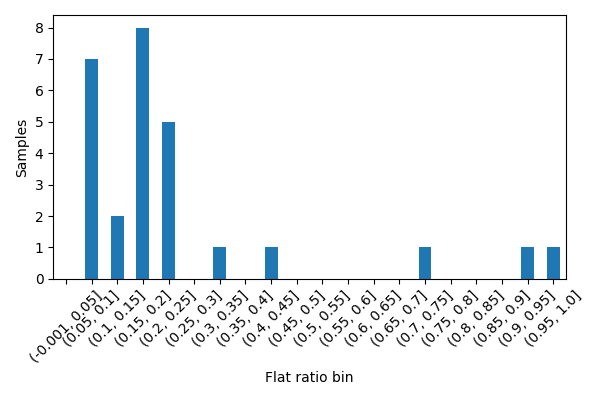

In [ ]:
plt.close(fig)

eda_quality_binned = pd.DataFrame(eda_flatline_ratio_df)
bin_edges = np.linspace(0, 1, 21)
eda_quality_binned["flat_bin"] = pd.cut(eda_quality_binned["flat_signal_rate"], bins=bin_edges, include_lowest=True)

bin_counts = (
    eda_quality_binned.loc[eda_quality_binned["flat_bin"].cat.codes >= 1, "flat_bin"].value_counts().sort_index()
)

plt.figure(figsize=(6, 4))
bin_counts.plot.bar(rot=45, ylabel="Samples", xlabel="Flat ratio bin")
plt.tight_layout()